# **Olivetti Faces**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

In [3]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, Flatten, Dropout , Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [4]:
data = fetch_olivetti_faces(shuffle=True)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\ammer\scikit_learn_data


In [5]:
x = data.images
y = data.target

In [6]:
set(y)

{0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39}

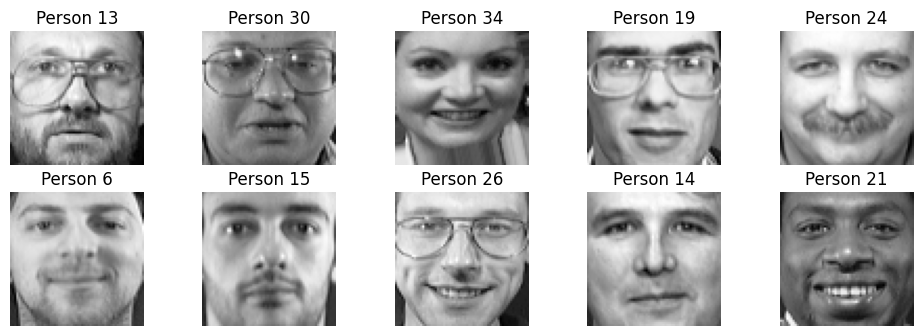

In [7]:
plt.figure(figsize=(12,8))

for i in range(10):
  plt.subplot(4, 5, i+1)
  plt.imshow(x[i], cmap='gray')
  plt.title(f'Person {y[i]}')
  plt.axis('off')

In [8]:
x = np.expand_dims(x, -1)

In [9]:
x.shape

(400, 64, 64, 1)

In [10]:
x = np.repeat(x, 3, axis=-1)

In [11]:
x.shape

(400, 64, 64, 3)

In [12]:
x = np.array([np.resize(img, (75, 75, 3)) for img in x])

In [13]:
y = to_categorical(y, num_classes=40)

In [14]:
y[1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0.], dtype=float32)

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [16]:
x_train.shape

(320, 75, 75, 3)

In [17]:
x_test.shape

(80, 75, 75, 3)

In [18]:
y_train.shape

(320, 40)

In [19]:
y_test.shape

(80, 40)

# **Training InveptionV3 with pretrained ImageNet weights**

In [20]:
base_model_pretrained = InceptionV3(weights='imagenet', include_top=False, input_shape=(75, 75, 3))

87910968/87910968 [==============================] - 28s 0us/step


In [21]:
for layer in base_model_pretrained.layers:
  layer.trainable = False

In [22]:
from tensorflow.keras.layers import GlobalAvgPool2D

In [23]:
x = GlobalAvgPool2D()(base_model_pretrained.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(40, activation='softmax')(x)

model = Model(inputs=base_model_pretrained.input, outputs=output)

In [24]:
model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
history_pre = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=16)

Epoch 1/50
20/20 [==============================] - 15s 146ms/step - loss: 3.8870 - accuracy: 0.0344 - val_loss: 3.7858 - val_accuracy: 0.0000e+00
Epoch 2/50
20/20 [==============================] - 1s 34ms/step - loss: 3.7912 - accuracy: 0.0406 - val_loss: 3.7363 - val_accuracy: 0.0250
Epoch 3/50
20/20 [==============================] - 1s 32ms/step - loss: 3.6641 - accuracy: 0.0594 - val_loss: 3.6998 - val_accuracy: 0.0125
Epoch 4/50
20/20 [==============================] - 1s 35ms/step - loss: 3.6193 - accuracy: 0.0562 - val_loss: 3.6711 - val_accuracy: 0.0125
Epoch 5/50
20/20 [==============================] - 1s 35ms/step - loss: 3.5431 - accuracy: 0.0719 - val_loss: 3.6386 - val_accuracy: 0.0125
Epoch 6/50
20/20 [==============================] - 1s 35ms/step - loss: 3.4912 - accuracy: 0.1219 - val_loss: 3.6061 - val_accuracy: 0.0250
Epoch 7/50
20/20 [==============================] - 1s 37ms/step - loss: 3.4300 - accuracy: 0.1250 - val_loss: 3.5810 - val_accuracy: 0.0375
Epoch 8

In [26]:
loss_pre, acc_pre = model.evaluate(x_test, y_test)

3/3 [==============================] - 3s 27ms/step - loss: 2.5605 - accuracy: 0.3375


In [27]:
loss_pre

2.5605337619781494

In [28]:
acc_pre

0.3375000059604645

# **Training InceptionV3 from scratch (no pretrained weights)**

In [29]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Concatenate, Input
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, Activation, BatchNormalization
from tensorflow.keras.models import Model

## Inception-A Block

In [30]:
def inception_a(x):
  # Branch 1 >> 1x1 Conv
  branch1 = Conv2D(64, (1,1), padding='same', activation='relu')(x)

  # branch 2 >> 1x1 Conv > 3x3 Conv
  branch2 = Conv2D(48, (1,1), padding='same', activation='relu')(x)
  branch2 = Conv2D(64, (3,3), padding='same', activation='relu')(branch2)

  # branch 3 >> 1x1 Conv > 3x3 Conv > 3x3 Conv
  branch3 = Conv2D(64, (1,1), padding='same', activation='relu')(x)
  branch3 = Conv2D(96, (3,3), padding='same', activation='relu')(branch3)
  branch3 = Conv2D(96, (3,3), padding='same', activation='relu')(branch3)

  # branch 4 >> Avg Pooling > 1x1
  branch4 = AveragePooling2D(pool_size=(3,3), strides=1, padding='same')(x)
  branch4 = Conv2D(32, (1,1), padding='same', activation='relu')(branch4)

  # Concatenate all branches
  output = Concatenate()([branch1, branch2, branch3, branch4])
  return output


## Reduction-A Block

In [31]:
def reduction_a(x):
  branch1 = Conv2D(384, (3,3),strides=2, padding='valid', activation='relu')(x)

  branch2 = Conv2D(64, (1,1), padding='same', activation='relu')(x)
  branch2 = Conv2D(96, (3,3), padding='same', activation='relu')(branch2)
  branch2 = Conv2D(96, (3,3), strides=2, padding='valid', activation='relu')(branch2)

  branch3 = AveragePooling2D(pool_size=(3,3), strides=2, padding='valid')(x)

  output = Concatenate()([branch1, branch2, branch3])
  return output

## Inception-B Block

In [32]:
def inception_b(x):
    branch1 = Conv2D(192, (1,1), padding='same', activation='relu')(x)

    branch2 = Conv2D(128, (1,1), padding='same', activation='relu')(x)
    branch2 = Conv2D(128, (1,7), padding='same', activation='relu')(branch2)
    branch2 = Conv2D(128, (7,1), padding='same', activation='relu')(branch2)

    branch3 = Conv2D(128, (1,1), padding='same', activation='relu')(x)
    branch3 = Conv2D(128, (7,1), padding='same', activation='relu')(branch3)
    branch3 = Conv2D(128, (1,7), padding='same', activation='relu')(branch3)
    branch3 = Conv2D(128, (7,1), padding='same', activation='relu')(branch3)
    branch3 = Conv2D(128, (1,7), padding='same', activation='relu')(branch3)

    branch4 = AveragePooling2D(pool_size=(3,3), strides=1, padding='same')(x)
    branch4 = Conv2D(192, (1,1), padding='same', activation='relu')(branch4)

    output = Concatenate()([branch1, branch2, branch3, branch4])
    return output


## Reduction-B Block

In [33]:
def reduction_b(x):
    branch1 = Conv2D(192, (1,1), padding='same', activation='relu')(x)
    branch1 = Conv2D(320, (3,3), strides=2, padding='valid', activation='relu')(branch1)

    branch2 = Conv2D(192, (1,1), padding='same', activation='relu')(x)
    branch2 = Conv2D(192, (1,7), padding='same', activation='relu')(branch2)
    branch2 = Conv2D(192, (7,1), padding='same', activation='relu')(branch2)
    branch2 = Conv2D(192, (3,3), strides=2, padding='valid', activation='relu')(branch2)

    branch3 = AveragePooling2D(pool_size=(3,3), strides=2, padding='valid')(x)

    output = Concatenate()([branch1, branch2, branch3])
    return output


## Inception-C Block

In [34]:
def inception_c(x):
  branch1 = Conv2D(320, (1,1), padding='same', activation='relu')(x)

  branch2 = Conv2D(384, (1,1), padding='same', activation='relu')(x)
  branch2a = Conv2D(384, (1,3), padding='same', activation='relu')(branch2)
  branch2b = Conv2D(384, (3,1), padding='same', activation='relu')(branch2)
  branch2 = Concatenate()([branch2a, branch2b])

  branch3 = Conv2D(448, (1,1), padding='same', activation='relu')(x)
  branch3 = Conv2D(384, (3,3), padding='same', activation='relu')(branch3)
  branch3a = Conv2D(384, (1,3), padding='same', activation='relu')(branch3)
  branch3b = Conv2D(384, (3,1), padding='same', activation='relu')(branch3)
  branch3 = Concatenate()([branch3a, branch3b])

  branch4 = AveragePooling2D(pool_size=(3,3), strides=1, padding='same')(x)
  branch4 = Conv2D(192, (1,1), padding='same', activation='relu')(branch4)

  output = Concatenate()([branch1, branch2, branch3, branch4])
  return output

## Model

In [35]:
# Stem Block
input_layer = Input(shape=(299, 299, 3))

x = Conv2D(32, (3,3), strides=2, padding='valid', activation='relu')(input_layer)
x = Conv2D(32, (3,3), strides=2, padding='valid', activation='relu')(x)
x = Conv2D(64, (3,3), strides=2, padding='same', activation='relu')(x)
x = MaxPooling2D(pool_size=(3,3), strides=2)(x)

x = Conv2D(80, (1,1), padding='valid', activation='relu')(x)
x = Conv2D(192, (3,3), padding='valid', activation='relu')(x)
x = MaxPooling2D(pool_size=(3,3), strides=2)(x)


# Inception Modules
x = inception_a(x)
x = inception_a(x)
x = inception_a(x)
x = reduction_a(x)

x = inception_b(x)
x = inception_b(x)
x = inception_b(x)
x = inception_b(x)
x = reduction_b(x)

x = inception_c(x)
x = inception_c(x)

# Classification Head
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(5749, activation='softmax')(x)

In [36]:
data = fetch_olivetti_faces(shuffle=True)

In [37]:
x_data = data.images
y_data = data.target

In [38]:
x_data = np.expand_dims(x_data, -1)
x_data = np.repeat(x_data, 3, axis=-1)

In [39]:
import cv2

In [40]:
x_resized = np.array([cv2.resize(img, (299, 299)) for img in x_data])

In [41]:
x_resized = x_resized / 255.0

In [42]:
y_cat = to_categorical(y_data, num_classes=40)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(x_resized, y_cat, test_size=0.2, random_state=42)

In [44]:
model = Model(inputs=input_layer, outputs=output)

In [45]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
# history = model.fit(
#     X_train, y_train,
#     validation_data=(X_test, y_test),
#     epochs=10,
#     batch_size=16
# )

In [48]:
from sklearn.datasets import fetch_lfw_people

In [49]:
import numpy as np

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
data = fetch_lfw_people(min_faces_per_person=20, resize=0.5)

In [52]:
x_data = data.images
y_data = data.target

In [53]:
x_data.shape

(3023, 62, 47)

In [54]:
X_resized = np.array([cv2.resize(img, (299, 299)) for img in x_data])
X_resized = np.stack([X_resized]*3, axis=-1)
X_resized = X_resized / 255.0

In [55]:
y_categorical = to_categorical(y_data, num_classes =5749)

In [56]:
len(X_resized)

3023

In [57]:
len(y_categorical)

3023

In [58]:
X_train, X_val, y_train, y_val = train_test_split(X_resized, y_categorical, test_size=0.2, random_state=42)

In [59]:
model = Model(inputs=input_layer, outputs=output)

In [60]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [61]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
76/76 [==============================] - 26s 170ms/step - loss: 4.6913 - accuracy: 0.1687 - val_loss: 3.8083 - val_accuracy: 0.1603
Epoch 2/10
76/76 [==============================] - 10s 132ms/step - loss: 3.7549 - accuracy: 0.1791 - val_loss: 3.7505 - val_accuracy: 0.1603
Epoch 3/10
76/76 [==============================] - 11s 139ms/step - loss: 3.7503 - accuracy: 0.1791 - val_loss: 3.7548 - val_accuracy: 0.1603
Epoch 4/10
76/76 [==============================] - 10s 133ms/step - loss: 3.7322 - accuracy: 0.1791 - val_loss: 3.7572 - val_accuracy: 0.1603
Epoch 5/10
76/76 [==============================] - 22s 291ms/step - loss: 3.7284 - accuracy: 0.1791 - val_loss: 3.7480 - val_accuracy: 0.1603
Epoch 6/10
76/76 [==============================] - 31s 320ms/step - loss: 3.7155 - accuracy: 0.1791 - val_loss: 3.7536 - val_accuracy: 0.1603
Epoch 7/10
76/76 [==============================] - 61s 808ms/step - loss: 3.7160 - accuracy: 0.1791 - val_loss: 3.7213 - val_accuracy: 0.1603

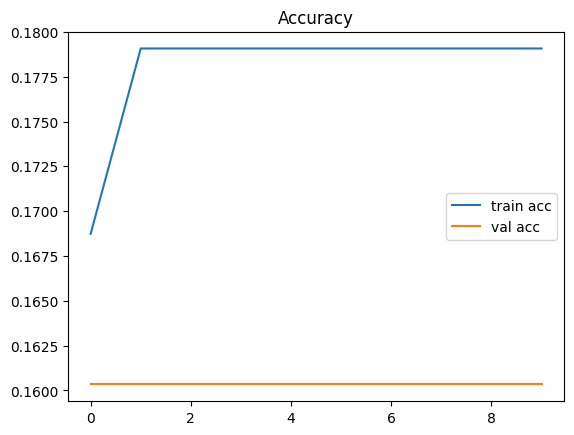

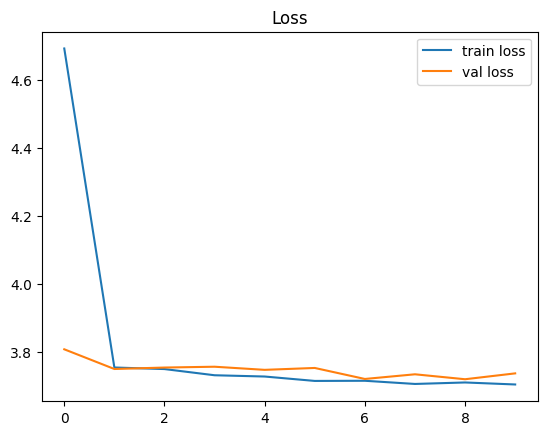

In [62]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()
